## Wine Quality Prediction usin ANN in TensorFlow

### 1. Importing Libraries

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [69]:
red_wine_url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/42-Wine%20Quality%20Prediction/redwinequality.csv"
white_wine_url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/42-Wine%20Quality%20Prediction/whitewinequality.csv"

In [71]:
red = pd.read_csv(red_wine_url, sep=';')
white = pd.read_csv(white_wine_url, sep=';')

red['type'] = 1
white['type'] = 0

df = pd.concat([red, white], ignore_index=True)
df.dropna(inplace=True)

### 3. Data Preprocessing

1. Exploratory Data Analysis

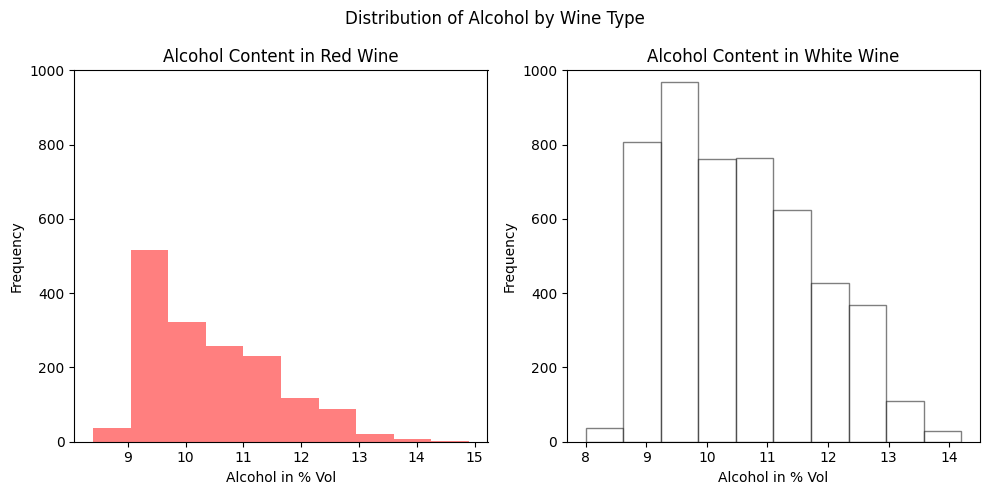

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(df[df['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(df[df['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

2. Train Test Split

In [73]:
X = df.iloc[:, :-1]
y = df['type']

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4. Build the Model

In [79]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(12, activation='relu', input_dim=12),
    tf.keras.layers.Dense(9, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           117 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283 (1.11 KB)

 Trainable params: 283 (1.11 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Compile and Fit the Model

In [92]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=1,
    verbose=1
)

Epoch 1/5
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9752 - loss: 0.0748 - val_accuracy: 0.9746 - val_loss: 0.0888
Epoch 2/5
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9773 - loss: 0.0684 - val_accuracy: 0.9692 - val_loss: 0.0968
Epoch 3/5
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9783 - loss: 0.0726 - val_accuracy: 0.9777 - val_loss: 0.0864
Epoch 4/5
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9802 - loss: 0.0656 - val_accuracy: 0.9731 - val_loss: 0.0928
Epoch 5/5
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9788 - loss: 0.0672 - val_accuracy: 0.9738 - val_loss: 0.0966


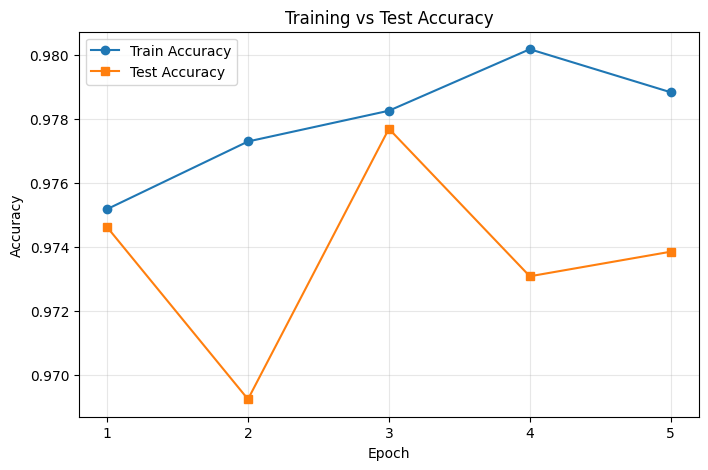

In [93]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], marker='s', label='Test Accuracy')
plt.title('Training vs Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

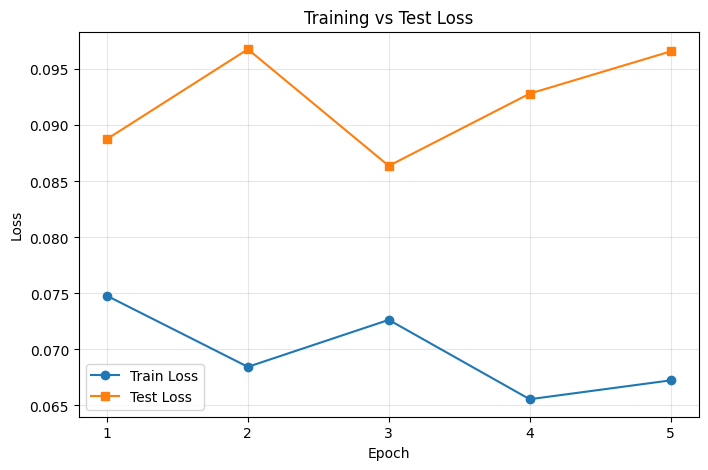

In [96]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history['loss'], marker='o', label='Train Loss')
plt.plot(epochs, history.history['val_loss'], marker='s', label='Test Loss')
plt.title('Training vs Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6. Make Prediction

In [82]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


### 7. Evaluate the Model

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

accuracy = accuracy_score(y_test, y_pred_labels)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.97


In [88]:
cm = confusion_matrix(y_test, y_pred_labels)
cm

array([[927,  32],
       [ 12, 329]])

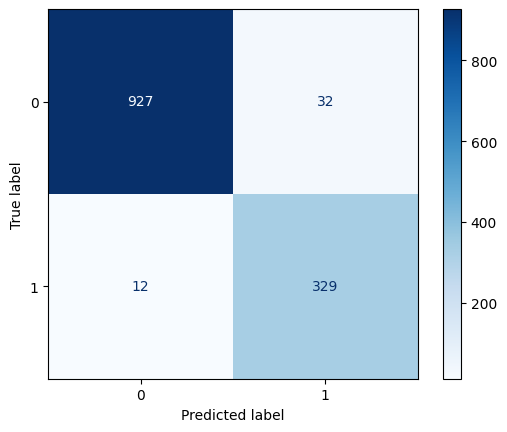

In [90]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.show()